# Hyperparameter Heston
## Convergence (Epochs)


In [1]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

# Sweep
import itertools


In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")


Cloning into '/content/fys5429'...
remote: Enumerating objects: 829, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 829 (delta 105), reused 119 (delta 51), pack-reused 654 (from 1)
Receiving objects: 100% (829/829), 64.05 MiB | 34.30 MiB/s, done.
Resolving deltas: 100% (407/407), done.
Working directory: /content/fys5429/code/notebooks


### Colab setup


In [3]:
# Pathways
data_path = Path("..") / "data" / "generated" / "hs_collocation.parquet"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda")
else:
    out_dir = Path("..") / "plots" / "eda"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")


Mounted at /content/drive
Plots will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda


In [4]:
# Importing HSPINN() Class
import sys
sys.path.insert(0, "../scripts")
from hspinn import HSPINN
from train_hs import train_pinn


### Global parameters


In [5]:
# Answer to the universe and everything
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Adding torch backends
torch.backends.cudnn.benchmark = True

# Option Physics for Heston
S_max = 300.0
T_max = 1.0
K = 100.0
r = 0.05
v_min = 0.01
v_max = 1.0
v0 = 0.04 

# Heston specific parameters
kappa = 2.0    # mean-reversion speed
theta = 0.04   # long-run variance
xi = 0.3       # vol-of-vol
rho = -0.7     # correlation

# NN Architecture (Sweep 1)
HIDDEN_LAYERS = 3
NEURONS_PER_LAYER = 256
ACTIVATION = 'tanh'

# Training Parameters (Sweep 2)
LEARNING_RATE = 5e-3

# Loss Weights (Sweep 3)
LAMBDA_PDE = 10.0
LAMBDA_IC  = 10.0
LAMBDA_BC  = 5.0

# Epoch Sweep values
CONV_EPOCHS_VALUES = [5000, 10000, 15000, 20000, 25000]


Using device: cuda


In [6]:
# Check if data exists
if not data_path.exists():
    raise FileNotFoundError(f"Collocation data not found at {data_path}. Please run generate_hs.ipynb first.")
else:
    df_all = pd.read_parquet(data_path)
    print(f"Loaded existing data from {data_path} (S_max={df_all['S'].max():.0f})")

# Extract tensors for Heston (S, v, tau)
def extract_tensors(df_subset):
    S_tensor = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    v_tensor = torch.tensor(df_subset['v'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau_tensor = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S_tensor, v_tensor, tau_tensor

df_interior = df_all[df_all['point_type'] == 'interior']
S_in, v_in, tau_in = extract_tensors(df_interior)

df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, v_ic, tau_ic = extract_tensors(df_ic)

# Combine all boundary condition points (S_lower, S_upper, v_lower, v_upper)
df_bc = df_all[df_all['point_type'].str.startswith('boundary')]
S_bc, v_bc, tau_bc = extract_tensors(df_bc)

print(f"Interior points: {len(S_in)}")
print(f"IC points:       {len(S_ic)}")
print(f"BC points:       {len(S_bc)}")


Loaded existing data from ../data/generated/hs_collocation.parquet (S_max=300)
Interior points: 10000
IC points:       2000
BC points:       1000


In [7]:
sweep_results = []
start_time = time.time()
total_runs = len(CONV_EPOCHS_VALUES)

header = f"{'#':>3} | {'Epochs':>8} | {'PDE Loss':>12} {'IC Loss':>12} {'BC Loss':>12} | {'Time':>6} {'ETA':>8}"
print(header)
print("─" * len(header))

for i, epochs in enumerate(CONV_EPOCHS_VALUES):
    run_start = time.time()
    result = train_pinn(S_in, v_in, tau_in, 
                        S_ic, v_ic, tau_ic, 
                        S_bc, v_bc, tau_bc,
                        r, K, kappa, theta, xi, rho, 
                        device,
                        LAMBDA_PDE, LAMBDA_IC, LAMBDA_BC, epochs,
                        lr=LEARNING_RATE, hidden_layers=HIDDEN_LAYERS,
                        neurons=NEURONS_PER_LAYER, activation='tanh')

    result['epochs'] = epochs
    sweep_results.append(result)

    run_sec = time.time() - run_start
    total_elapsed = time.time() - start_time
    eta = (total_elapsed / (i + 1)) * (total_runs - i - 1)

    print(f"{i+1:>3} | {epochs:>8} | "
          f"{result['final_pde']:>12.6f} {result['final_ic']:>12.6f} {result['final_bc']:>12.6f} | "
          f"{run_sec:>5.0f}s {eta:>6.0f}s")

elapsed = time.time() - start_time
print("─" * len(header))
print(f"Sweep complete: {len(sweep_results)} runs in {int(elapsed//60)}m {int(elapsed%60):02d}s")


  # |   Epochs |     PDE Loss      IC Loss      BC Loss |   Time      ETA
─────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  1 |     5000 |     6.199924    31.919510   200.018539 |    51s    204s
  2 |    10000 |     3.463765    16.982660   156.371002 |    93s    216s
  3 |    15000 |     2.899307    13.068432   144.157867 |   139s    189s
  4 |    20000 |     2.526309    11.017559   139.279984 |   185s    117s
  5 |    25000 |     2.064686     9.809253   135.881958 |   230s      0s
─────────────────────────────────────────────────────────────────────────
Sweep complete: 5 runs in 11m 38s


In [8]:
df_sweep = pd.DataFrame([{
    'epochs': r['epochs'],
    'pde_loss': r['final_pde'],
    'ic_loss': r['final_ic'],
    'bc_loss': r['final_bc'],
    'total_loss': r['final_total'],
} for r in sweep_results])

df_sweep = df_sweep.sort_values('pde_loss')
print(df_sweep.to_string(index=False))


 epochs  pde_loss   ic_loss    bc_loss  total_loss
  25000  2.064686  9.809253 135.881958  798.149170
  20000  2.526309 11.017559 139.279984  831.838623
  15000  2.899307 13.068432 144.157867  880.466675
  10000  3.463765 16.982660 156.371002  986.319214
   5000  6.199924 31.919510 200.018539 1381.287109


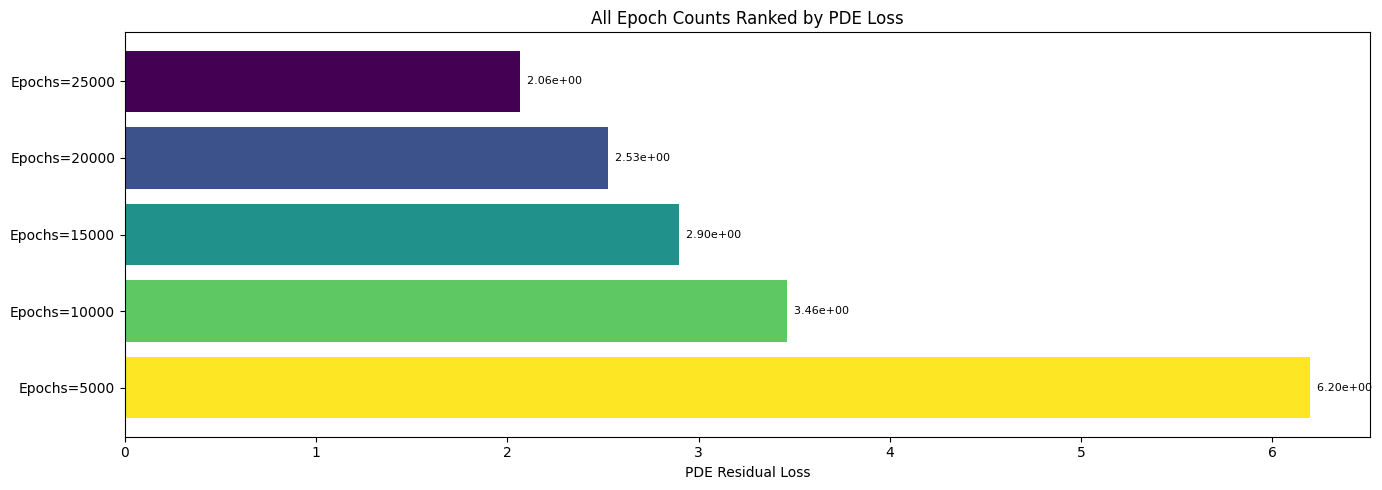

In [9]:
df_ranked = df_sweep.sort_values('pde_loss').reset_index(drop=True)
labels = [f"Epochs={r.epochs:.0f}" for _, r in df_ranked.iterrows()]

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_ranked)))
bars = ax.barh(range(len(df_ranked)), df_ranked['pde_loss'], color=colors)
ax.set_yticks(range(len(df_ranked)))
ax.set_yticklabels(labels)
ax.set_xlabel('PDE Residual Loss')
ax.set_title('All Epoch Counts Ranked by PDE Loss')
ax.invert_yaxis()

for i, v in enumerate(df_ranked['pde_loss']):
    ax.text(v, i, f'  {v:.2e}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(out_dir / "hyper_hs_conv_ranked.pdf", bbox_inches="tight")
plt.show()


### Loss Curves (All Runs)


KeyError: 'loss_history'

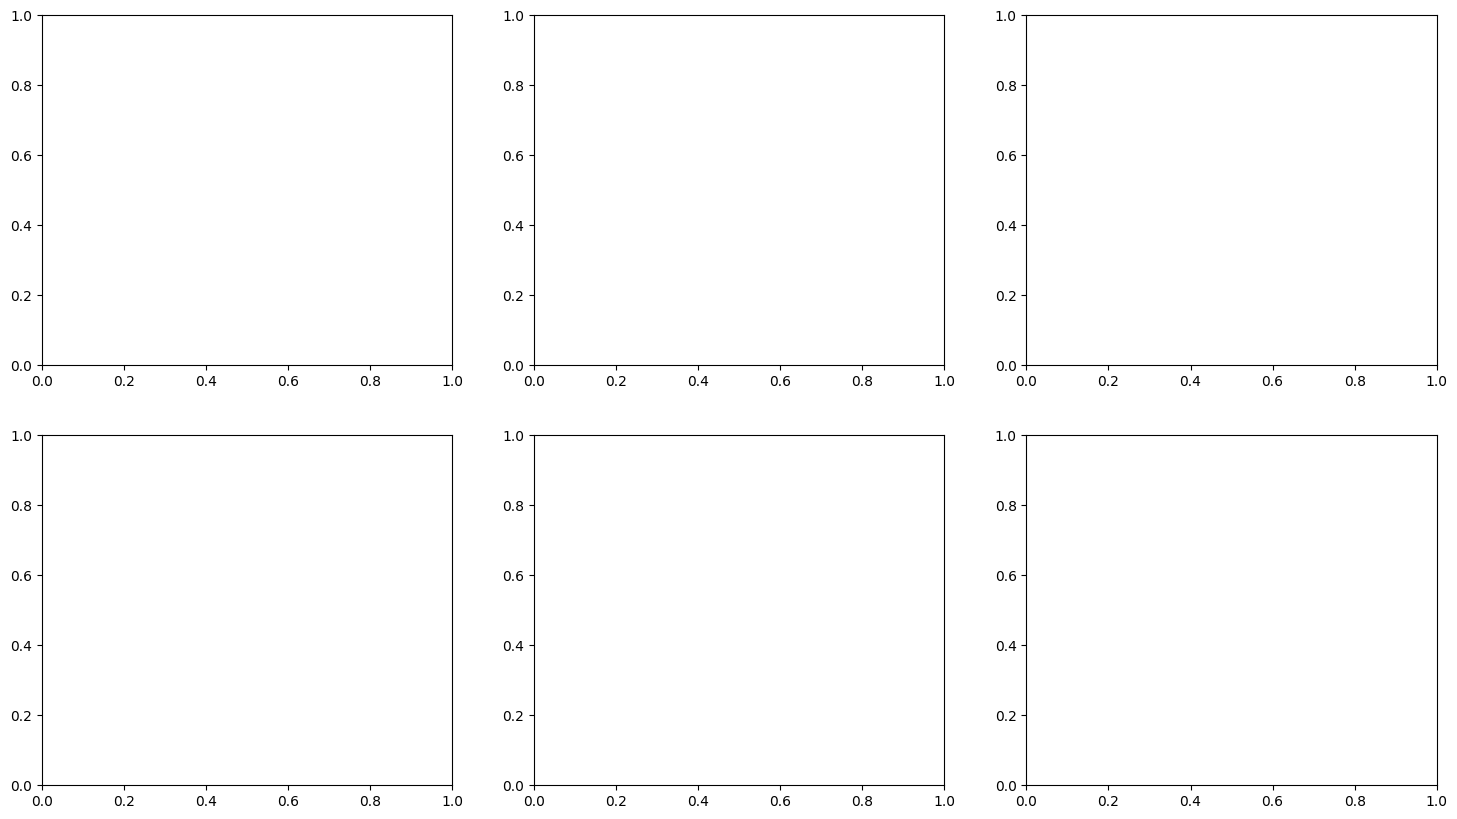

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, run in enumerate(sweep_results):
    ax = axes[i]
    history = run['loss_history']
    
    # Extract columns from history: [total, pde, ic, bc]
    total_loss = [h[0] for h in history]
    pde_loss = [h[1] for h in history]
    ic_loss = [h[2] for h in history]
    bc_loss = [h[3] for h in history]
    
    epochs_range = range(1, len(history) + 1)
    
    ax.plot(epochs_range, total_loss, label='Total Loss', color='black', linewidth=1.5)
    ax.plot(epochs_range, pde_loss, label='PDE Loss', alpha=0.8, linestyle='--')
    ax.plot(epochs_range, ic_loss, label='IC Loss', alpha=0.8, linestyle=':')
    ax.plot(epochs_range, bc_loss, label='BC Loss', alpha=0.8, linestyle='-.')
    
    ax.set_yscale('log')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.set_title(f"Epochs: {run['epochs']} (Final PDE: {run['final_pde']:.2e})")
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.savefig(out_dir / "hyper_hs_conv_curves.pdf", bbox_inches="tight")
plt.show()


In [ ]:
if IN_COLAB:
    from google.colab import drive
    drive.flush_and_unmount()
    print("Google Drive flushed and unmounted safely.")
